In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [24]:
X = np.array([
    [1, 4, 1.5, 3.8],
    [3, 6, 1.0, 3.1],
    [4, 7, 0.8, 3.9],
    [6, 8, 0.4, 3.4],
    [7, 9, 0.2, 2.8]
])

# W=[5,10,-2,0.5]
y = np.array([ 45.9 ,  76.55,  92.35, 112.9 , 128.  ])

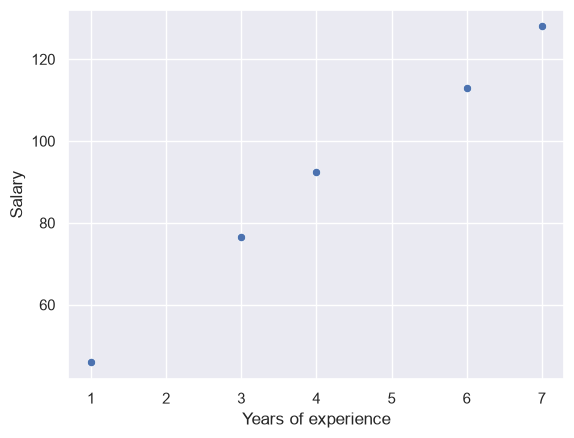

In [25]:
# Visualize the relationship between experience and salary

sns.scatterplot(x= X[:,0:1].ravel(), y= y)
plt.xlabel("Years of experience")
plt.ylabel("Salary")
plt.show()

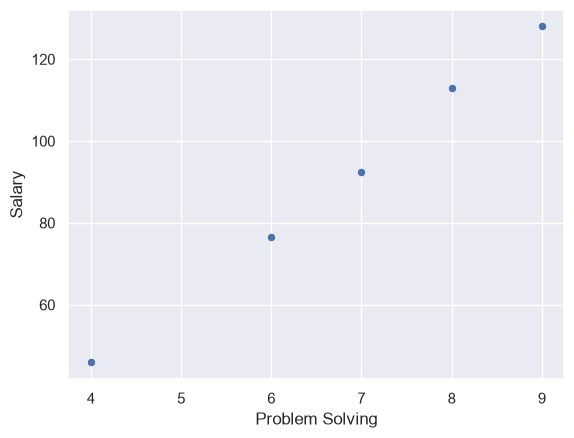

In [26]:
# Visualize the relationship between problem solving and salary

sns.scatterplot(x= X[:,1:2].ravel(), y= y)
plt.xlabel("Problem Solving")
plt.ylabel("Salary")
plt.show()

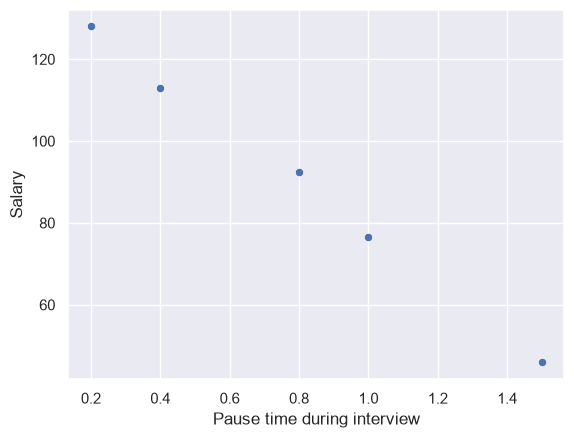

In [27]:
# Visualize the relationship between pause time and salary

sns.scatterplot(x= X[:,2:3].ravel(), y= y)
plt.xlabel("Pause time during interview")
plt.ylabel("Salary")
plt.show()

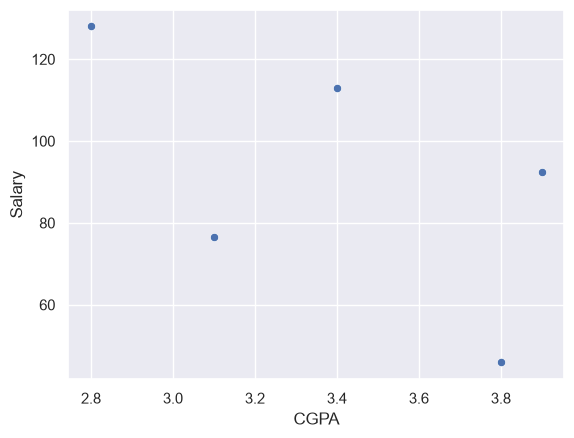

In [28]:
# Visualize the relationship between cgpa and salary

sns.scatterplot(x= X[:,3:].ravel(), y= y)
plt.xlabel("CGPA")
plt.ylabel("Salary")
plt.show()

In [29]:
#Prediction Function
"""Calculates the model output: f(x) = wx+b"""
def make_prediction(X, W, b):
    m = X.shape[0]      # kotogulo data point ache
    pred_list = np.zeros((m,))    #joto gulo datapoint initially toto gulo zeros(empty array)

    for i in range(m):
        # X[i] = feature vector, w = weights_vestor
        pred_list[i] = np.dot(W,X[i])+b   # y = wx+b

    return pred_list

In [30]:
m = X.shape[0]
n = X.shape[1]

W_init = np.ones((n,))
b_init = 1

make_prediction(X, W_init, b_init)

array([11.3, 14.1, 16.7, 18.8, 20. ])

# Cost Function 

In [31]:
def compute_cost (X,y,W,b):
    m = X.shape[0]      # kotogulo data point ache
    total_cost = 0.0

    pred_list = make_prediction(X,W,b)
    # print(f"pred_list : {pred_list}")


    error = pred_list - y
    # print(f"error : {error}")

    error_squared = error ** 2
    # print(f"error_squared : {error_squared}")

    total_cost = np.sum(error_squared)
    cost = (total_cost/(2*m))
    return cost

In [32]:
W_init = np.ones((n,))
b_init = 1

print(f"Model cost : {compute_cost(X,y,W_init, b_init)}")

Model cost : 3133.8895


# Gradient

In [33]:
def calculate_gradient(X,y, W,b):
    m = X.shape[0]                  # kotogulo data point ache
    n = X.shape[1]
    dj_dw = np.zeros((n,))          # jotota features totota weights
    dj_db = 0.0                     # Change neede for bias
    for i in range(m):
        predictions = np.dot(W,X[i]) + b   # y = wx+b
        error = predictions - y[i]

        for j in range(n):
            dj_dw[j] = dj_dw[j] + (error* X[i,j])  # i = data point, j = feature; error × feature value যোগ করে weight gradient updatew

        # The bias gradient is just the sum of errors
        dj_db = dj_db + (error)
    dj_dw = dj_dw / m 
    dj_db = dj_db / m
    return dj_dw, dj_db

In [34]:
W_init = np.ones((n,))
b_init = 1

print(f"Gradient : {calculate_gradient(X,y,W_init, b_init)}")

Gradient : (array([-369.03 , -553.49 ,  -46.822, -248.49 ]), np.float64(-74.96000000000001))


# Cost Optimization using Gradient Descent

In [35]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
    """Automates the tuning of w and b to minimize cost"""
    w = w_input
    b = b_input
    cost_memo = []
    iteration = []
    for i in range(max_iter):
        # 1. Calculate the dradients(the slope)
        dj_dw, dj_db = calculate_gradient(X,y, w,b)
        # 2. update parameters by taking a small step(alpha) against the gradient
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # 3. Track progress by saving the cost
        cost = compute_cost(X,y, w, b)
        cost_memo.append(cost)
        iteration.append(i)

        #Log the status every 100 steps
        if i % 100 == 0:
            print(f"iteration {i}, cost:{cost:0.4f} , dj_dw:{dj_dw}, dj_db:{dj_db}, w:{w}, b:{b:0.4f}")

    return w, b, cost_memo, iteration

In [42]:
W_init = np.zeros((n,))
b_init = 0.0


w_final, b_final, cost_memo, iter = gradient_descent(X, y, w_input = W_init, b_input = b_init, max_iter = 10000, alpha = 0.01)

iteration 0, cost:156.1039 , dj_dw:[-443.67  -668.91   -58.008 -302.83 ], dj_db:-91.14, w:[4.4367  6.6891  0.58008 3.0283 ], b:0.9114
iteration 100, cost:0.2098 , dj_dw:[-0.22813628 -0.05864     0.1660582   0.40032538], dj_db:0.06331085583785949, w:[ 6.9123284   8.13950271 -0.26204608  1.85090047], b:0.7323
iteration 200, cost:0.1555 , dj_dw:[ 0.04414774 -0.0692271  -0.0045622   0.08929593], dj_db:-0.00334103833398558, w:[ 6.94596089  8.20635679 -0.30628534  1.67135256], b:0.7166
iteration 300, cost:0.1422 , dj_dw:[ 0.05827911 -0.06692009 -0.01369624  0.06699873], dj_db:-0.006766264873328964, w:[ 6.89119981  8.27458222 -0.29493507  1.59722801], b:0.7225
iteration 400, cost:0.1302 , dj_dw:[ 0.0567367  -0.06396552 -0.01302088  0.06252647], dj_db:-0.006358586708975622, w:[ 6.83349662  8.34000876 -0.2814525   1.5327401 ], b:0.7291
iteration 500, cost:0.1193 , dj_dw:[ 0.05434933 -0.06110576 -0.01181208  0.05929749], dj_db:-0.005749899275774339, w:[ 6.77796238  8.40251909 -0.26903968  1.4718

In [37]:
print(w_final)
print(b_final)

[ 5.11679847 10.08161726 -1.14469963  0.49011382]
0.3208761870054485


In [38]:
X = np.array([
    [1, 4, 1.5, 3.8],
    [3, 6, 1.0, 3.1],
    [4, 7, 0.8, 3.9],
    [6, 8, 0.4, 3.4],
    [7, 9, 0.2, 2.8]
])


make_prediction(X, W=[5,10,-2,0.5], b=2)

array([ 45.9 ,  76.55,  92.35, 112.9 , 128.  ])

In [39]:
make_prediction(X,W=w_final, b= b_final)

array([ 45.90952676,  76.53562836,  92.35507507, 112.88311221,
       128.01639957])

# Regression Through Scikit earn

In [ ]:
from sklearn.linear_model import LinearRegression # Dataset choto hole eita use korbo
from sklearn.linear_model import SGDRegressor     # Dataset boro or messy hole eita use korbo

In [41]:
model1 = LinearRegression()

# learning
model1.fit(X,y)

weights = model1.coef_
bias = model1.intercept_

print(weights)
print(bias)

[ 5.  10.  -2.   0.5]
2.000000000000071


In [47]:
model2 = SGDRegressor(penalty = None, max_iter=10000, learning_rate= "constant")

model2.fit(X,y)

weights_2 = model2.coef_
bias_2 = model2.intercept_[0] # sdg te bias 1D array te ase, kintu amr scaler value lagbe. Tai [0] likhte hoy

print(weights_2)
print(bias_2)

[ 6.95829941  8.22704471 -0.19549007  1.78538876]
0.7564015672269585


In [45]:
make_prediction(X, weights, bias)

array([ 45.9 ,  76.55,  92.35, 112.9 , 128.  ])

In [48]:
make_prediction(X,weights_2, bias_2)

array([ 47.11412197,  76.33278311,  92.98553624, 114.31468142,
       128.46789029])